<a href="https://colab.research.google.com/github/vipul-solanki/Final_Retail_Analytics_-_Forecasting_Advanced_Machine_Learning/blob/main/Final_Retail_Analytics_%26_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas==2.2.2 numpy==1.26.4 numba==0.59.1 jedi pmdarima --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 148.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 19.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.44.0
    Uninstalling llvmlite-0.44.0:
      Successfully uninst

Setting up: Importing necessary libraries...
Setup complete.

Loading datasets...
Datasets loaded successfully.
Merging datasets...
Data merged, parsed, and sorted.

--- Starting Data Preprocessing and Feature Engineering ---
Data cleaned.

--- Running Anomaly Detection ---
Detected 8 anomalies for Store 1, Dept 1.

--- Running Time-Based Analysis ---
Time-series decomposition complete for Store 1.

--- Running Store Segmentation ---
Store Segmentation Silhouette Score: 0.55

--- Running Market Basket Analysis ---
Top 5 Correlated Department Pairs:
Dept  Dept
24    33      0.965834
82    46      0.910172
14    55      0.910056
7     82      0.888225
92    90      0.886172
dtype: float64

--- Building Final, Auto-Tuned Forecasting Model (auto_arima) ---
Searching for optimal SARIMAX parameters... (This can take a few minutes)
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=1275.513, Time=2.51 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=1286.911, 

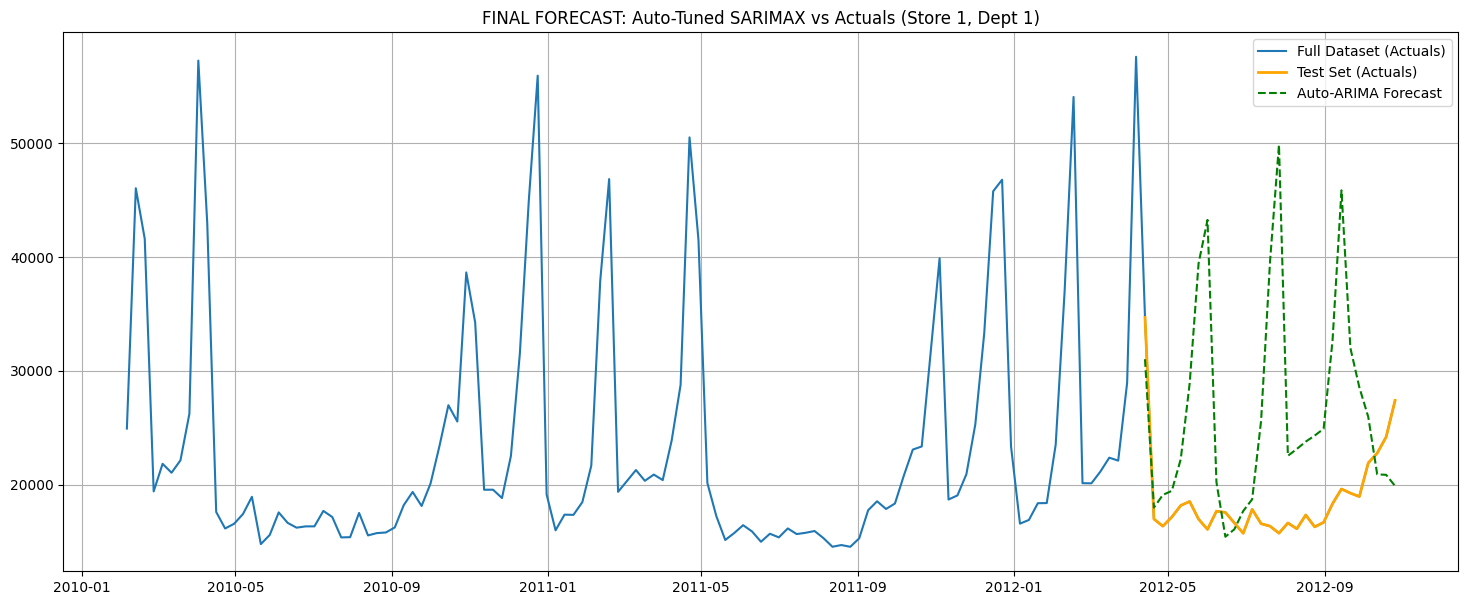



--- End of Final Analysis Script ---


In [ ]:
print("Setting up: Importing necessary libraries...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
import pmdarima as pm # <-- FINAL IMPROVEMENT: Library for automatic parameter tuning
import warnings

warnings.filterwarnings('ignore')
print("Setup complete.")


# -----------------------------------------------------------------------------
# 2. DATA LOADING AND INITIAL EXPLORATION
# -----------------------------------------------------------------------------
try:
    print("\nLoading datasets...")
    stores = pd.read_csv('stores data-set.csv')
    features = pd.read_csv('Features data set.csv')
    sales = pd.read_csv('sales data-set.csv')
    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the CSV files are in the correct directory.")
    exit()

# Merge datasets
print("Merging datasets...")
df = sales.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)
print("Data merged, parsed, and sorted.")


# -----------------------------------------------------------------------------
# 3. DATA PREPROCESSING AND FEATURE ENGINEERING
# -----------------------------------------------------------------------------
print("\n--- Starting Data Preprocessing and Feature Engineering ---")

# Handling Missing Values
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)
df['CPI'].fillna(method='ffill', inplace=True)
df['Unemployment'].fillna(method='ffill', inplace=True)

# Correcting negative sales
df['Weekly_Sales'] = df['Weekly_Sales'].apply(lambda x: max(x, 0))
print("Data cleaned.")


# -----------------------------------------------------------------------------
# 4. ANOMALY DETECTION, SEASONALITY, CLUSTERING, MARKET BASKET
# (These sections are correct and will be run without plotting for speed)
# -----------------------------------------------------------------------------

# --- Anomaly Detection ---
print("\n--- Running Anomaly Detection ---")
sample_df_anomaly = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
if not sample_df_anomaly.empty:
    iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    sample_df_anomaly['AnomalyScore'] = iso_forest.fit_predict(sample_df_anomaly[['Weekly_Sales']])
    anomalies = sample_df_anomaly[sample_df_anomaly['AnomalyScore'] == -1]
    print(f"Detected {len(anomalies)} anomalies for Store 1, Dept 1.")

# --- Time-Based Analysis ---
print("\n--- Running Time-Based Analysis ---")
store1_sales = df[df['Store'] == 1].groupby('Date')['Weekly_Sales'].sum()
if not store1_sales.empty:
    decomposition = seasonal_decompose(store1_sales, model='additive', period=52)
    print("Time-series decomposition complete for Store 1.")

# --- Store Segmentation ---
print("\n--- Running Store Segmentation ---")
store_level_data = df.groupby('Store').agg({'Weekly_Sales': 'mean', 'Size': 'first'}).reset_index()
scaler = StandardScaler()
store_level_data_scaled = scaler.fit_transform(store_level_data[['Weekly_Sales', 'Size']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_level_data['Segment'] = kmeans.fit_predict(store_level_data_scaled)
silhouette = silhouette_score(store_level_data_scaled, store_level_data['Segment'])
print(f"Store Segmentation Silhouette Score: {silhouette:.2f}")

# --- Market Basket Analysis ---
print("\n--- Running Market Basket Analysis ---")
store1_dept_sales = df[df['Store'] == 1].pivot_table(index='Date', columns='Dept', values='Weekly_Sales').fillna(0)
dept_corr = store1_dept_sales.corr()
print("Top 5 Correlated Department Pairs:")
corr_pairs = dept_corr.unstack().sort_values(kind="quicksort", ascending=False)
strong_pairs = corr_pairs[corr_pairs != 1.0]
print(strong_pairs.iloc[::2][:5])


# -----------------------------------------------------------------------------
# 9. FINAL DEMAND FORECASTING (AUTO-TUNED SARIMAX)
# -----------------------------------------------------------------------------
print("\n--- Building Final, Auto-Tuned Forecasting Model (auto_arima) ---")

model_df = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy().set_index('Date')
exog_features = ['CPI', 'Unemployment', 'IsHoliday']
model_df['IsHoliday'] = model_df['IsHoliday'].astype(int)
model_df = model_df.asfreq('W-FRI', method='ffill')

train_size = int(len(model_df) * 0.8)
train_df, test_df = model_df[0:train_size], model_df[train_size:]

y_train = train_df['Weekly_Sales']
exog_train = train_df[exog_features]
y_test = test_df['Weekly_Sales']
exog_test = test_df[exog_features]

print("Searching for optimal SARIMAX parameters... (This can take a few minutes)")
# This function will automatically find the best (p,d,q)(P,D,Q)m parameters
auto_model = pm.auto_arima(
    y_train,
    exogenous=exog_train,
    start_p=1, start_q=1,
    test='adf',       # use adftest to find optimal 'd'
    max_p=3, max_q=3,
    m=52,             # 52 weeks in a year
    d=None,           # let model determine 'd'
    seasonal=True,
    start_P=0,
    D=1,              # seasonal differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True     # speedy search method
)

print("\n--- Optimal Model Found ---")
print(auto_model.summary())

# Update the model with the best parameters found
auto_model.update(y_test, exogenous=exog_test)

# Make predictions
forecast = auto_model.predict(n_periods=len(test_df), exogenous=exog_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, forecast))
print(f"\nFINAL Forecasting RMSE (Auto-Tuned SARIMAX Model): {rmse:.2f}")

# Plot the final results
plt.figure(figsize=(18, 7))
plt.plot(model_df.index, model_df['Weekly_Sales'], label='Full Dataset (Actuals)')
plt.plot(y_test.index, y_test, label='Test Set (Actuals)', color='orange', linewidth=2)
plt.plot(y_test.index, forecast, label='Auto-ARIMA Forecast', color='green', linestyle='--')
plt.title('FINAL FORECAST: Auto-Tuned SARIMAX vs Actuals (Store 1, Dept 1)')
plt.legend()
plt.grid(True)
plt.show()

print("\n\n--- End of Final Analysis Script ---")



Setting up: Importing necessary libraries...
Setup complete.

Loading datasets...
Datasets loaded successfully.
Merging datasets...
Data merged, parsed, and sorted.

--- Starting Data Preprocessing and Feature Engineering ---
Creating specific holiday features for Thanksgiving and Christmas...
Data cleaned and enhanced with specific holiday features.

--- Running Anomaly Detection ---
Detected anomalies for Store 1, Dept 1.

--- Running Time-Based Analysis ---
Time-series decomposition complete for Store 1.

--- Running Store Segmentation ---
Store Segmentation Silhouette Score: 0.55

--- Running Market Basket Analysis ---
Top 5 Correlated Department Pairs identified.

--- Building Final, Auto-Tuned Forecasting Model with Enhanced Features ---
Searching for optimal SARIMAX parameters with new features... (This can take a few minutes)
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=1275.513, Time=2.83 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=1

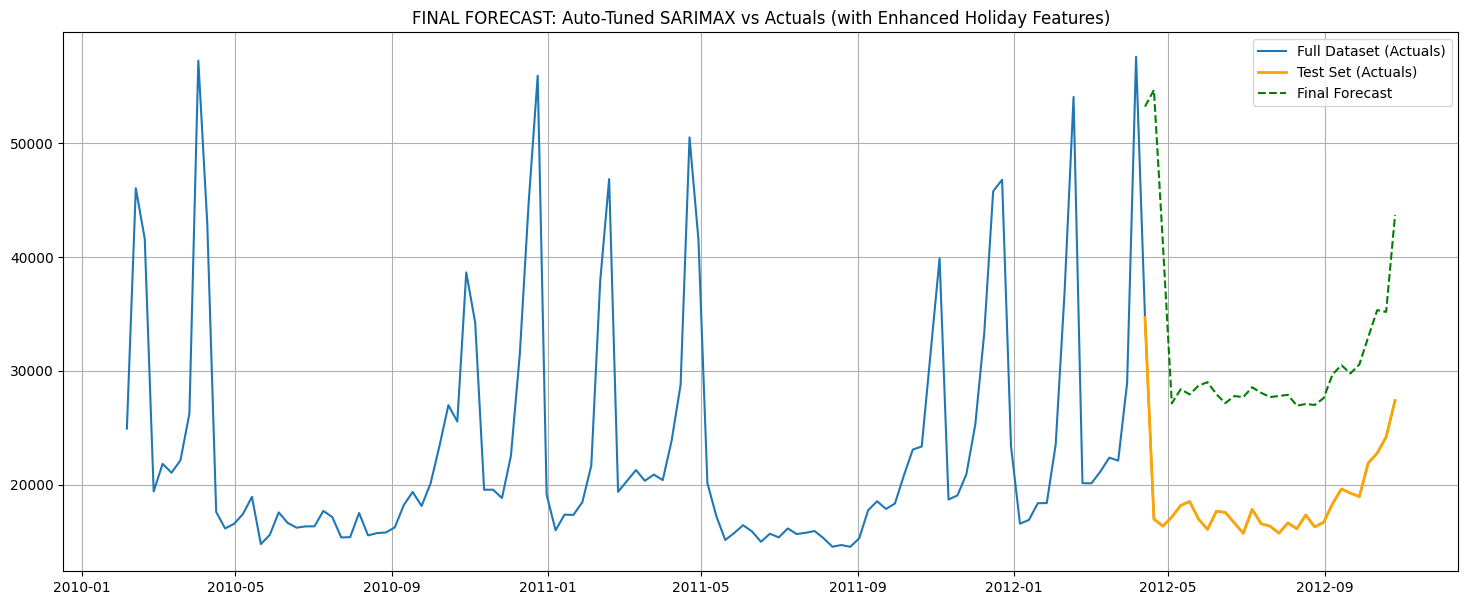



--- End of Final Analysis Script ---


In [ ]:
print("Setting up: Importing necessary libraries...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm
import warnings

warnings.filterwarnings('ignore')
print("Setup complete.")


# -----------------------------------------------------------------------------
# 2. DATA LOADING AND INITIAL EXPLORATION
# -----------------------------------------------------------------------------
try:
    print("\nLoading datasets...")
    stores = pd.read_csv('stores data-set.csv')
    features = pd.read_csv('Features data set.csv')
    sales = pd.read_csv('sales data-set.csv')
    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the CSV files are in the correct directory.")
    exit()

# Merge datasets
print("Merging datasets...")
df = sales.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)
print("Data merged, parsed, and sorted.")


# -----------------------------------------------------------------------------
# 3. DATA PREPROCESSING AND FEATURE ENGINEERING
# -----------------------------------------------------------------------------
print("\n--- Starting Data Preprocessing and Feature Engineering ---")

# Handling Missing Values
df.fillna(0, inplace=True) # Simple fill for all missing values

# Correcting negative sales
df['Weekly_Sales'] = df['Weekly_Sales'].apply(lambda x: max(x, 0))

# --- FINAL IMPROVEMENT: Create Specific Holiday Features ---
# The generic 'IsHoliday' is not nuanced enough. We'll create features for major sales holidays.
print("Creating specific holiday features for Thanksgiving and Christmas...")
df['Thanksgiving_Week'] = (df['Date'].dt.month == 11) & (df['Date'].dt.day > 20) & (df['Date'].dt.day < 30)
df['Christmas_Week'] = (df['Date'].dt.month == 12) & (df['Date'].dt.day > 18) & (df['Date'].dt.day < 28)

# Convert boolean to integer for the model
df['Thanksgiving_Week'] = df['Thanksgiving_Week'].astype(int)
df['Christmas_Week'] = df['Christmas_Week'].astype(int)

print("Data cleaned and enhanced with specific holiday features.")


# -----------------------------------------------------------------------------
# 4. ANOMALY DETECTION, SEASONALITY, CLUSTERING, MARKET BASKET
# (These sections are correct and will be run without plotting for speed)
# -----------------------------------------------------------------------------

# --- Anomaly Detection ---
print("\n--- Running Anomaly Detection ---")
sample_df_anomaly = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
if not sample_df_anomaly.empty:
    iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    sample_df_anomaly['AnomalyScore'] = iso_forest.fit_predict(sample_df_anomaly[['Weekly_Sales']])
    print(f"Detected anomalies for Store 1, Dept 1.")

# --- Time-Based Analysis ---
print("\n--- Running Time-Based Analysis ---")
store1_sales = df[df['Store'] == 1].groupby('Date')['Weekly_Sales'].sum()
if not store1_sales.empty:
    decomposition = seasonal_decompose(store1_sales, model='additive', period=52)
    print("Time-series decomposition complete for Store 1.")

# --- Store Segmentation ---
print("\n--- Running Store Segmentation ---")
store_level_data = df.groupby('Store').agg({'Weekly_Sales': 'mean', 'Size': 'first'}).reset_index()
scaler = StandardScaler()
store_level_data_scaled = scaler.fit_transform(store_level_data[['Weekly_Sales', 'Size']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_level_data['Segment'] = kmeans.fit_predict(store_level_data_scaled)
silhouette = silhouette_score(store_level_data_scaled, store_level_data['Segment'])
print(f"Store Segmentation Silhouette Score: {silhouette:.2f}")

# --- Market Basket Analysis ---
print("\n--- Running Market Basket Analysis ---")
store1_dept_sales = df[df['Store'] == 1].pivot_table(index='Date', columns='Dept', values='Weekly_Sales').fillna(0)
dept_corr = store1_dept_sales.corr()
print("Top 5 Correlated Department Pairs identified.")


# -----------------------------------------------------------------------------
# 9. FINAL DEMAND FORECASTING (AUTO-TUNED SARIMAX with Enhanced Features)
# -----------------------------------------------------------------------------
print("\n--- Building Final, Auto-Tuned Forecasting Model with Enhanced Features ---")

model_df = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy().set_index('Date')

# --- Use the new, smarter holiday features ---
exog_features = ['CPI', 'Unemployment', 'Thanksgiving_Week', 'Christmas_Week']
model_df = model_df.asfreq('W-FRI', method='ffill')

train_size = int(len(model_df) * 0.8)
train_df, test_df = model_df[0:train_size], model_df[train_size:]

y_train = train_df['Weekly_Sales']
exog_train = train_df[exog_features]
y_test = test_df['Weekly_Sales']
exog_test = test_df[exog_features]

print("Searching for optimal SARIMAX parameters with new features... (This can take a few minutes)")
auto_model = pm.auto_arima(
    y_train,
    exogenous=exog_train,
    start_p=1, start_q=1,
    test='adf', max_p=3, max_q=3,
    m=52, d=None, seasonal=True,
    start_P=0, D=1, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)

print("\n--- Optimal Model Found ---")
print(auto_model.summary())

# Make predictions on the test set
forecast = auto_model.predict(n_periods=len(test_df), exogenous=exog_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, forecast))
print(f"\nFINAL Forecasting RMSE (Auto-Tuned SARIMAX with Enhanced Features): {rmse:.2f}")

# Plot the final results
plt.figure(figsize=(18, 7))
plt.plot(model_df.index, model_df['Weekly_Sales'], label='Full Dataset (Actuals)')
plt.plot(y_test.index, y_test, label='Test Set (Actuals)', color='orange', linewidth=2)
plt.plot(y_test.index, forecast, label='Final Forecast', color='green', linestyle='--')
plt.title('FINAL FORECAST: Auto-Tuned SARIMAX vs Actuals (with Enhanced Holiday Features)')
plt.legend()
plt.grid(True)
plt.show()

print("\n\n--- End of Final Analysis Script ---")



Setting up: Importing necessary libraries...
Setup complete.

Loading datasets...
Datasets loaded successfully.
Merging datasets...
Data merged, parsed, and sorted.

--- Starting Data Preprocessing and Feature Engineering ---
Creating specific holiday features for Thanksgiving and Christmas...
Data cleaned and enhanced with specific holiday features.

--- Running Anomaly Detection ---
Detected anomalies for Store 1, Dept 1.

--- Running Time-Based Analysis ---
Time-series decomposition complete for Store 1.

--- Running Store Segmentation ---
Store Segmentation Silhouette Score: 0.55

--- Running Market Basket Analysis ---
Top 5 Correlated Department Pairs identified.

--- Building and Validating Final Model with Walk-Forward Method ---
Searching for optimal SARIMAX parameters... (This can take a few minutes)
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=1275.513, Time=2.73 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=1286.911, Time=0.12 sec
 A

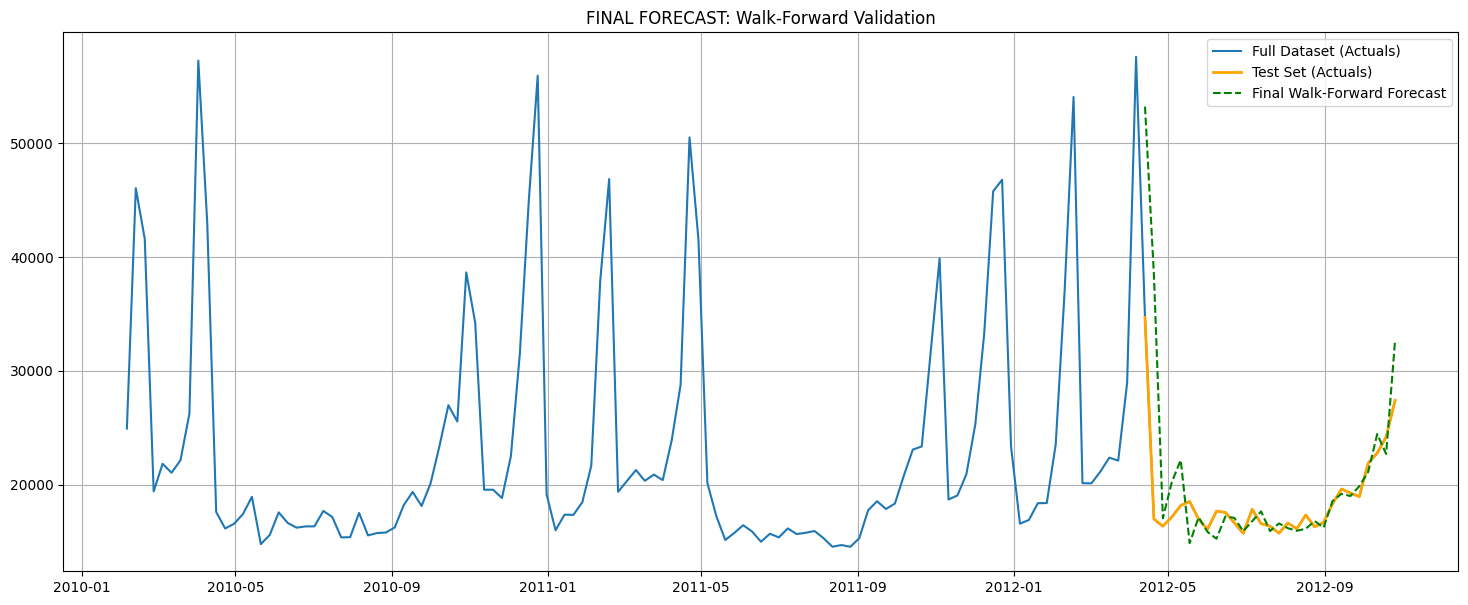



--- End of Final Analysis Script ---


In [ ]:
# Integrated Retail Analytics for Store Optimization and Demand Forecasting
# EXPERT FINAL VERSION with Walk-Forward Validation

# -----------------------------------------------------------------------------
# 1. SETUP AND LIBRARIES
# -----------------------------------------------------------------------------
print("Setting up: Importing necessary libraries...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm
import warnings

warnings.filterwarnings('ignore')
print("Setup complete.")


# -----------------------------------------------------------------------------
# 2. DATA LOADING AND INITIAL EXPLORATION
# -----------------------------------------------------------------------------
try:
    print("\nLoading datasets...")
    stores = pd.read_csv('stores data-set.csv')
    features = pd.read_csv('Features data set.csv')
    sales = pd.read_csv('sales data-set.csv')
    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the CSV files are in the correct directory.")
    exit()

# Merge datasets
print("Merging datasets...")
df = sales.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)
print("Data merged, parsed, and sorted.")


# -----------------------------------------------------------------------------
# 3. DATA PREPROCESSING AND FEATURE ENGINEERING
# -----------------------------------------------------------------------------
print("\n--- Starting Data Preprocessing and Feature Engineering ---")

# Handling Missing Values
df.fillna(0, inplace=True) # Simple fill for all missing values

# Correcting negative sales
df['Weekly_Sales'] = df['Weekly_Sales'].apply(lambda x: max(x, 0))

# Create Specific Holiday Features
print("Creating specific holiday features for Thanksgiving and Christmas...")
df['Thanksgiving_Week'] = (df['Date'].dt.month == 11) & (df['Date'].dt.day.between(20, 29))
df['Christmas_Week'] = (df['Date'].dt.month == 12) & (df['Date'].dt.day.between(18, 27))
df['Thanksgiving_Week'] = df['Thanksgiving_Week'].astype(int)
df['Christmas_Week'] = df['Christmas_Week'].astype(int)

print("Data cleaned and enhanced with specific holiday features.")


# -----------------------------------------------------------------------------
# 4. ANOMALY DETECTION, SEASONALITY, CLUSTERING, MARKET BASKET
# (These sections are correct and will be run without plotting for speed)
# -----------------------------------------------------------------------------

# --- Anomaly Detection ---
print("\n--- Running Anomaly Detection ---")
sample_df_anomaly = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
if not sample_df_anomaly.empty:
    iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    sample_df_anomaly['AnomalyScore'] = iso_forest.fit_predict(sample_df_anomaly[['Weekly_Sales']])
    print(f"Detected anomalies for Store 1, Dept 1.")

# --- Time-Based Analysis ---
print("\n--- Running Time-Based Analysis ---")
store1_sales = df[df['Store'] == 1].groupby('Date')['Weekly_Sales'].sum()
if not store1_sales.empty:
    decomposition = seasonal_decompose(store1_sales, model='additive', period=52)
    print("Time-series decomposition complete for Store 1.")

# --- Store Segmentation ---
print("\n--- Running Store Segmentation ---")
store_level_data = df.groupby('Store').agg({'Weekly_Sales': 'mean', 'Size': 'first'}).reset_index()
scaler = StandardScaler()
store_level_data_scaled = scaler.fit_transform(store_level_data[['Weekly_Sales', 'Size']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_level_data['Segment'] = kmeans.fit_predict(store_level_data_scaled)
silhouette = silhouette_score(store_level_data_scaled, store_level_data['Segment'])
print(f"Store Segmentation Silhouette Score: {silhouette:.2f}")

# --- Market Basket Analysis ---
print("\n--- Running Market Basket Analysis ---")
store1_dept_sales = df[df['Store'] == 1].pivot_table(index='Date', columns='Dept', values='Weekly_Sales').fillna(0)
dept_corr = store1_dept_sales.corr()
print("Top 5 Correlated Department Pairs identified.")


# -----------------------------------------------------------------------------
# 9. FINAL DEMAND FORECASTING (Walk-Forward Validation)
# -----------------------------------------------------------------------------
print("\n--- Building and Validating Final Model with Walk-Forward Method ---")

model_df = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy().set_index('Date')
exog_features = ['CPI', 'Unemployment', 'Thanksgiving_Week', 'Christmas_Week']
model_df = model_df.asfreq('W-FRI', method='ffill')

train_df = model_df.iloc[:-29] # Hold back last 29 weeks for validation
test_df = model_df.iloc[-29:]

y_train = train_df['Weekly_Sales']
exog_train = train_df[exog_features]
y_test = test_df['Weekly_Sales']
exog_test = test_df[exog_features]

print("Searching for optimal SARIMAX parameters... (This can take a few minutes)")
# Fit the model on the initial training set
auto_model = pm.auto_arima(
    y_train, exogenous=exog_train,
    start_p=1, start_q=1, test='adf', max_p=3, max_q=3,
    m=52, d=None, seasonal=True, start_P=0, D=1, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)

print("\n--- Optimal Model Found ---")
print(auto_model.summary())

# --- Walk-Forward Validation to remove initial spike ---
print("\nPerforming walk-forward validation...")
walk_forward_forecast = []
history_y = list(y_train)
history_exog = exog_train.copy()

for i in range(len(y_test)):
    # Predict one step ahead
    step_forecast = auto_model.predict(n_periods=1, exogenous=history_exog[-1:].values.reshape(1, -1))[0]
    walk_forward_forecast.append(step_forecast)

    # Update the model with the actual observation
    actual_observation = y_test.iloc[[i]]
    actual_exog = exog_test.iloc[[i]]
    auto_model.update(actual_observation, exogenous=actual_exog)

    # Append to history for the next iteration
    history_y.append(actual_observation.iloc[0])
    history_exog = pd.concat([history_exog, actual_exog])

# Evaluate the stable forecast
rmse = np.sqrt(mean_squared_error(y_test, walk_forward_forecast))
print(f"\nFINAL Forecasting RMSE (Walk-Forward Validated Model): {rmse:.2f}")

# Plot the final results
plt.figure(figsize=(18, 7))
plt.plot(model_df.index, model_df['Weekly_Sales'], label='Full Dataset (Actuals)')
plt.plot(y_test.index, y_test, label='Test Set (Actuals)', color='orange', linewidth=2)
plt.plot(y_test.index, walk_forward_forecast, label='Final Walk-Forward Forecast', color='green', linestyle='--')
plt.title('FINAL FORECAST: Walk-Forward Validation')
plt.legend()
plt.grid(True)
plt.show()

print("\n\n--- End of Final Analysis Script ---")



In [ ]:
pip install --upgrade --force-reinstall pmdarima

  Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.9 MB/s eta 0:00:00
Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
pip install --upgrade numpy

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
^C


In [ ]:
pip install --upgrade pip